In [4]:
pip install "numpy<2" pandas torch torchvision pillow matplotlib scikit-learn torch-snippets certifi ipython --break-system-packages

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


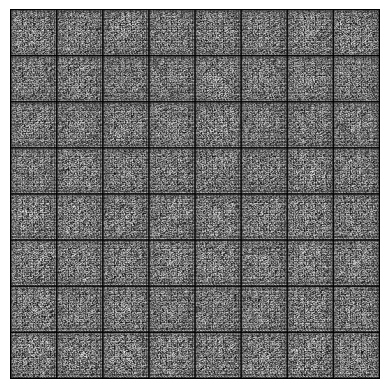

Epoch: 1


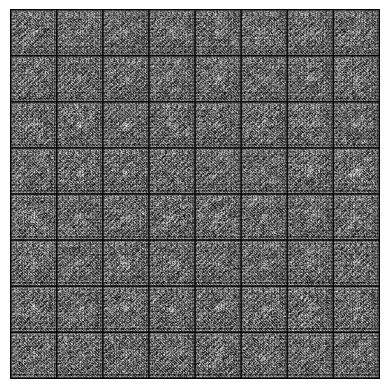

Epoch: 2


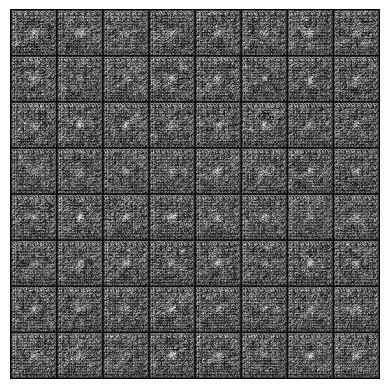

Epoch: 3


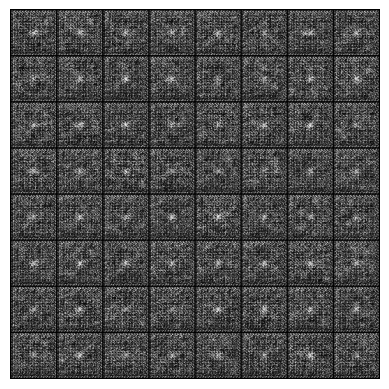

Epoch: 4


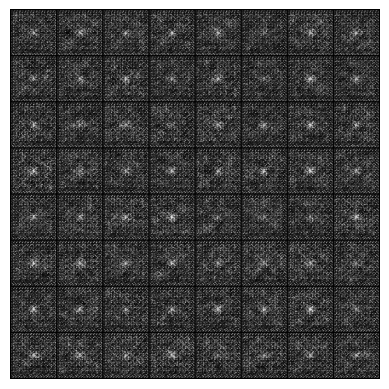

Epoch: 5


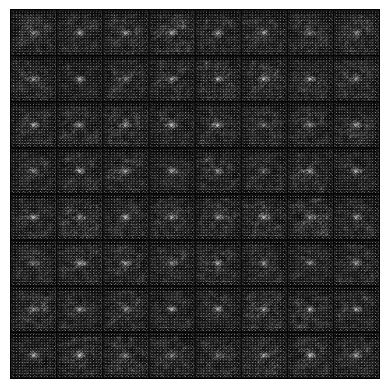

Epoch: 6


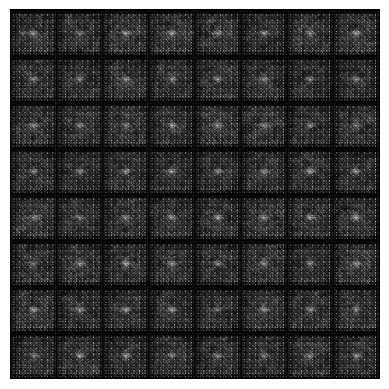

Epoch: 7


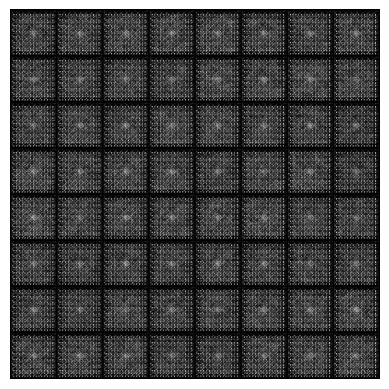

Epoch: 8


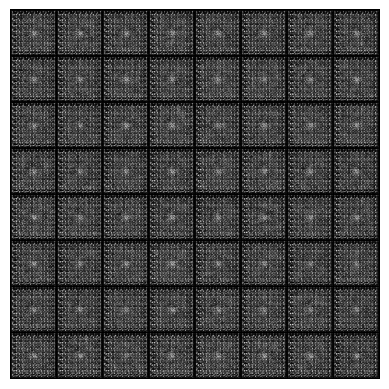

Epoch: 9


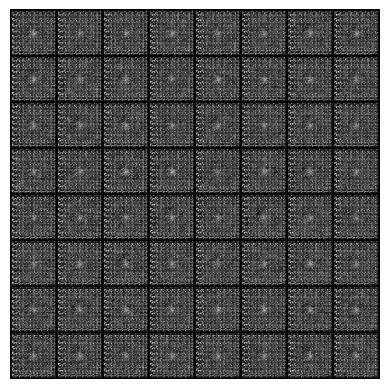

Epoch: 10


In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from PIL import Image
from sklearn.model_selection import train_test_split
import ssl
import certifi
from torch.optim import Adam

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

device = "cuda" if torch.cuda.is_available() else "cpu"

# galaxy folder reader
df = pd.read_csv("GALAXY_DATASET/final_15000.csv")
df.head()

img_folder = "GALAXY_DATASET/Images Differing sizes/224"

# 10 images are missing from the folder, drop those rows
valid = set(int(f.replace(".jpg", "")) for f in os.listdir(img_folder) if f.endswith(".jpg"))
df = df[df["asset_id"].isin(valid)].reset_index(drop=True)

# defines a loader for the galaxy dataset, returns img
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        path = os.path.join(self.img_dir, f"{int(row['asset_id'])}.jpg")
        img = Image.open(path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img
        
# separates into training data
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

train_tfms = transforms.Compose([
    transforms.Resize((64, 64)),      
    transforms.Grayscale(), # gray scale to reduce computational costs         
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

data_loader = DataLoader(GalaxyDataset(train_df, img_folder, train_tfms), batch_size=32, shuffle=True,  num_workers=1)

# DCGAN generator class, reduces down from a 256 channel input
class DCGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        # project noise + class one-hot into a (128, 7, 7) spatial feature map
        self.proj = nn.Linear(100, 256 * 4 * 4)
        self.net = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.proj(z)
        return self.net(x.view(-1, 256, 4, 4))

# DCGAN discriminator class
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # embed the class label into a 64x64 map
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, imgs):
        return self.net(imgs)


generator = DCGenerator().to(device)
discriminator = DCDiscriminator().to(device)

# optimizers
d_optimizer = Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = Adam(generator.parameters(),     lr=0.0002, betas=(0.5, 0.999))

# function that plots GAN-generated images into a 64 image grid
def plot_samples():
    z = noise(64)
    sample_images = generator(z).data.cpu()
    grid = make_grid(sample_images, nrow=8, normalize=True)
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.show()

# generates initial random noise image
def noise(batch_size):
    n = torch.randn(batch_size, 100)
    return n.to(device)

# loss function
loss = nn.BCELoss()

# trains the generator given fake_data, returns error
def generator_train_step(fake_data):
    n = len(fake_data)
    vec_ones = torch.ones(n, 1).to(device)

    g_optimizer.zero_grad()
    prediction = discriminator(fake_data)

    error = loss(prediction, vec_ones)
    error.backward()

    g_optimizer.step()
    return error

# trains the discriminator given real_data and fake_data, return real + fake error
def discriminator_train_step(real_data, fake_data):
    n = len(real_data)
    vec_ones = torch.ones(n, 1).to(device)
    vec_zeros = torch.zeros(n, 1).to(device)

    d_optimizer.zero_grad()

    prediction_real = discriminator(real_data)
    error_real = loss(prediction_real, vec_ones)
    error_real.backward()

    prediction_fake = discriminator(fake_data)
    error_fake = loss(prediction_fake, vec_zeros)
    error_fake.backward()

    d_optimizer.step()
    return error_real + error_fake

num_epochs = 450
# actually runs each epoch, plots 64 image grid every 50 epochs
for epoch in range(num_epochs):
    N = len(data_loader)

    for images in data_loader:
        n_images = len(images)
        real_data = images.to(device)

        fake_data = generator(noise(n_images)).to(device).detach()
        d_loss = discriminator_train_step(real_data, fake_data)

        fake_data = generator(noise(n_images)).to(device)
        g_loss = generator_train_step(fake_data)

    if (epoch + 1) % 50 == 0:
        plot_samples()
        print(f"Epoch: {epoch + 1}")